# Notebook 06 – SHAP Analysis & Coaching Recommendations

Covers scope steps 4–8:
- **Step 4**: Global SHAP summary — which features drive win prediction overall
- **Step 5**: Cohort SHAP — lower bracket (≤1790 Elo) vs upper bracket (>1790 Elo)
- **Step 6**: Cohort comparison function — percentile rank per feature vs peer group
- **Step 7**: Recommendation ranking — priority = SHAP importance × (1 − percentile/100)
- **Step 8**: End-to-end test on personal replays

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle, json, warnings
from pathlib import Path
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

try:
    import shap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
    import shap

print('shap version:', shap.__version__)

shap version: 0.51.0


In [2]:
DATA_DIR  = Path('../data')
MODEL_DIR = Path('../models')
PLOT_DIR  = Path('../plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

DELTA_CSV   = DATA_DIR / 'features_delta.csv'
MODEL_PKL   = MODEL_DIR / 'elocoach_model.pkl'
COHORT_PKL  = MODEL_DIR / 'cohort_distributions.pkl'
REPLAYS_CSV = DATA_DIR / 'parsed_replays.csv'

MY_PROFILE_ID = 3134896
RANDOM_STATE  = 42

## 2. Load Model & Recreate Train/Test Split

In [3]:
df = pd.read_csv(DELTA_CSV)
print(f'Loaded {len(df)} rows, {df.shape[1]} columns')
df.head(2)

Loaded 175 rows, 77 columns


,filepath,villagers_dark_age_delta,villagers_feudal_age_delta,villagers_castle_age_delta,villagers_imperial_age_delta,mil_trained_dark_age_delta,mil_trained_feudal_age_delta,mil_trained_castle_age_delta,mil_trained_imperial_age_delta,apm_dark_age_delta,...,stable_count_delta,archery_count_delta,blacksmith_count_delta,market_count_delta,duration_min,p1_elo,p2_elo,p1_civ,p2_civ,result
0,C:\Users\liher\Games\Age of Empires 2 DE\76561...,-13,5,-43,42,0,-2,-36,-99,38,...,-2,-1,-2,0,52.88,1478,1484,10,36,0
1,C:\Users\liher\Games\Age of Empires 2 DE\76561...,5,-4,35,4,0,4,11,215,-104,...,-9,0,1,1,54.66,1704,1742,6,22,0


In [4]:
META_COLS = ['result', 'filepath', 'duration_min', 'p1_elo', 'p2_elo', 'p1_civ', 'p2_civ']
delta_cols = [c for c in df.columns if c.endswith('_delta')]
print(f'{len(delta_cols)} delta feature columns')

X = df[delta_cols].copy()
y = df['result'].astype(int)

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Test set: {len(X_test)} rows')

70 delta feature columns
Test set: 35 rows


In [5]:
with open(MODEL_PKL, 'rb') as f:
    model = pickle.load(f)

print('Model loaded:', type(model).__name__)
print('Best params:', getattr(model, 'best_params_', 'N/A'))

Model loaded: XGBClassifier
Best params: N/A


In [6]:
# Extract the final XGBoost estimator (may be inside RandomizedSearchCV)
if hasattr(model, 'best_estimator_'):
    xgb_model = model.best_estimator_
else:
    xgb_model = model

print('Estimator type:', type(xgb_model).__name__)

Estimator type: XGBClassifier


## 3. Global SHAP Analysis

TreeExplainer on the XGBoost model. SHAP values quantify each feature's
contribution to shifting the prediction away from the base rate.

In [7]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
print('SHAP values shape:', shap_values.shape)

SHAP values shape: (35, 70)


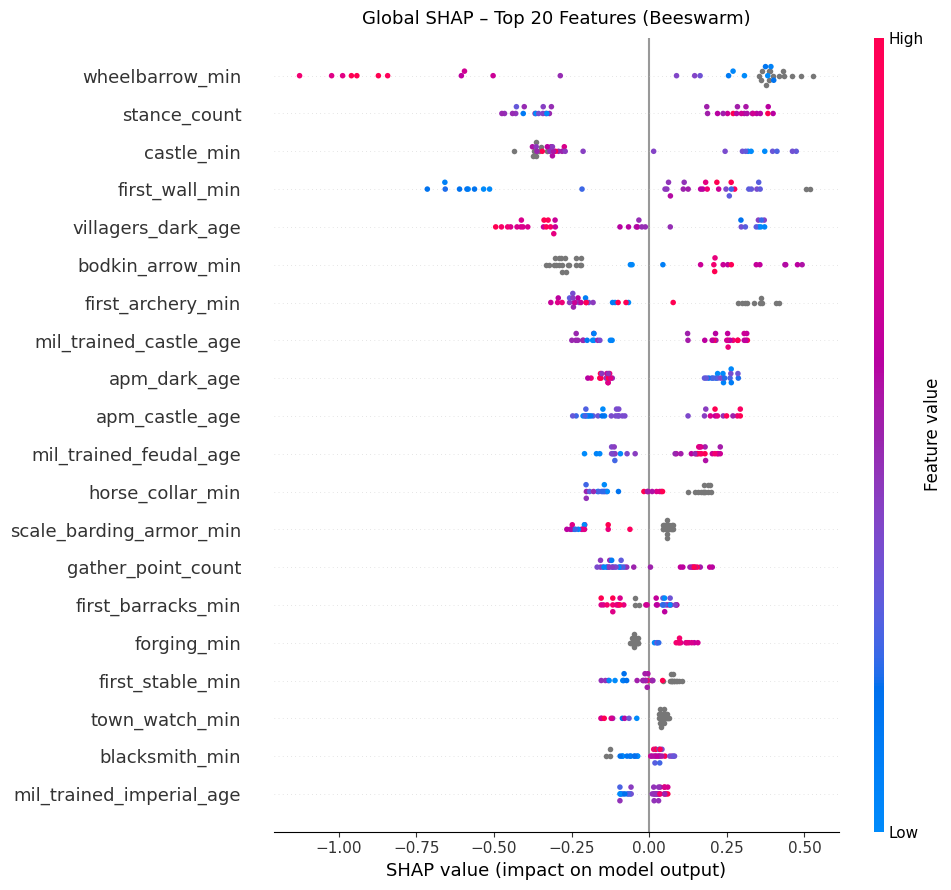

Saved shap_beeswarm_global.png


In [8]:
# ── Beeswarm summary plot ──────────────────────────────────────────────
short_labels = {c: c.replace('_delta', '') for c in delta_cols}

fig, ax = plt.subplots(figsize=(10, 9))
shap.summary_plot(
    shap_values, X_test,
    feature_names=[short_labels[c] for c in delta_cols],
    max_display=20,
    show=False,
    plot_size=None,
)
plt.title('Global SHAP – Top 20 Features (Beeswarm)', fontsize=13, pad=10)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'shap_beeswarm_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved shap_beeswarm_global.png')

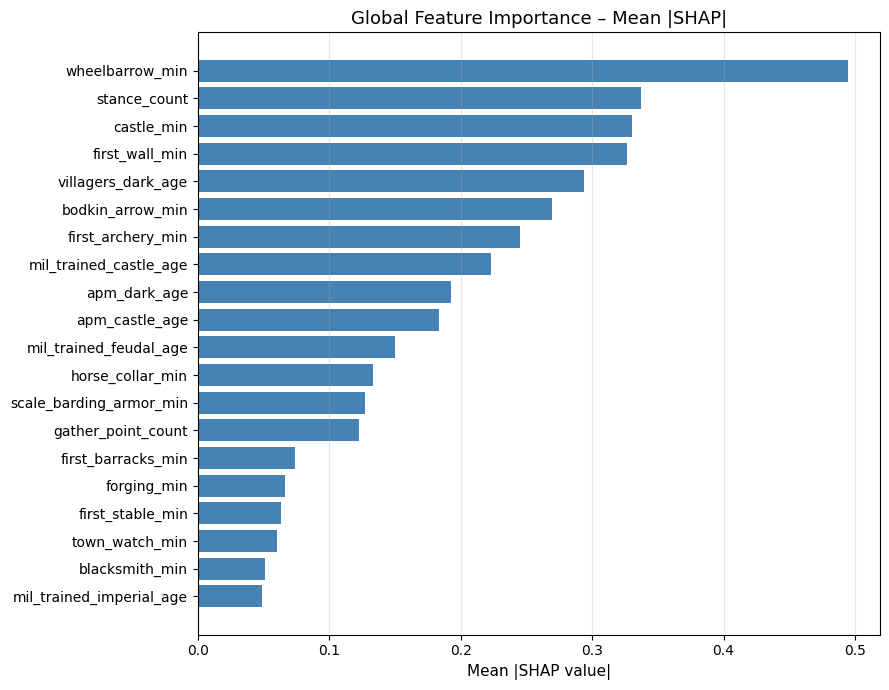

Top 10 features by mean |SHAP|:
               feature  mean_abs_shap
       wheelbarrow_min       0.494328
          stance_count       0.337367
            castle_min       0.330233
        first_wall_min       0.326176
    villagers_dark_age       0.293837
      bodkin_arrow_min       0.269773
     first_archery_min       0.245004
mil_trained_castle_age       0.222792
          apm_dark_age       0.192961
        apm_castle_age       0.183822


In [9]:
# ── Bar chart: mean |SHAP| ─────────────────────────────────────────────
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_df = pd.DataFrame({
    'feature': [short_labels[c] for c in delta_cols],
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(shap_df['feature'][::-1], shap_df['mean_abs_shap'][::-1], color='steelblue')
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title('Global Feature Importance – Mean |SHAP|', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'shap_bar_global.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features by mean |SHAP|:')
print(shap_df.head(10).to_string(index=False))

## 4. Cohort SHAP Analysis

Split the test set at the median Elo (~1790). Lower bracket = p1_elo ≤ median.
Compare which features dominate in each skill tier.

In [10]:
test_elo = df.loc[idx_test, 'p1_elo'].values
elo_median = df['p1_elo'].median()
print(f'Elo median: {elo_median:.0f}')

lower_mask = test_elo <= elo_median
upper_mask = ~lower_mask
print(f'Lower bracket (≤{elo_median:.0f}): {lower_mask.sum()} games')
print(f'Upper bracket (>{elo_median:.0f}): {upper_mask.sum()} games')

Elo median: 1787
Lower bracket (≤1787): 21 games
Upper bracket (>1787): 14 games


In [11]:
def cohort_mean_shap(mask):
    sv = shap_values[mask]
    return np.abs(sv).mean(axis=0)

shap_lower = cohort_mean_shap(lower_mask)
shap_upper = cohort_mean_shap(upper_mask)

# Build comparison dataframe
cohort_df = pd.DataFrame({
    'feature': [short_labels[c] for c in delta_cols],
    'lower': shap_lower,
    'upper': shap_upper,
})
cohort_df['max_shap'] = cohort_df[['lower', 'upper']].max(axis=1)
cohort_df = cohort_df.sort_values('max_shap', ascending=False).head(20).reset_index(drop=True)
print(cohort_df.head(10).to_string(index=False))

               feature    lower    upper  max_shap
       wheelbarrow_min 0.478441 0.518158  0.518158
        first_wall_min 0.297490 0.369204  0.369204
            castle_min 0.311547 0.358262  0.358262
          stance_count 0.347900 0.321568  0.347900
    villagers_dark_age 0.286155 0.305360  0.305360
      bodkin_arrow_min 0.252587 0.295552  0.295552
     first_archery_min 0.249839 0.237753  0.249839
mil_trained_castle_age 0.222129 0.223785  0.223785
          apm_dark_age 0.182549 0.208578  0.208578
        apm_castle_age 0.179016 0.191033  0.191033


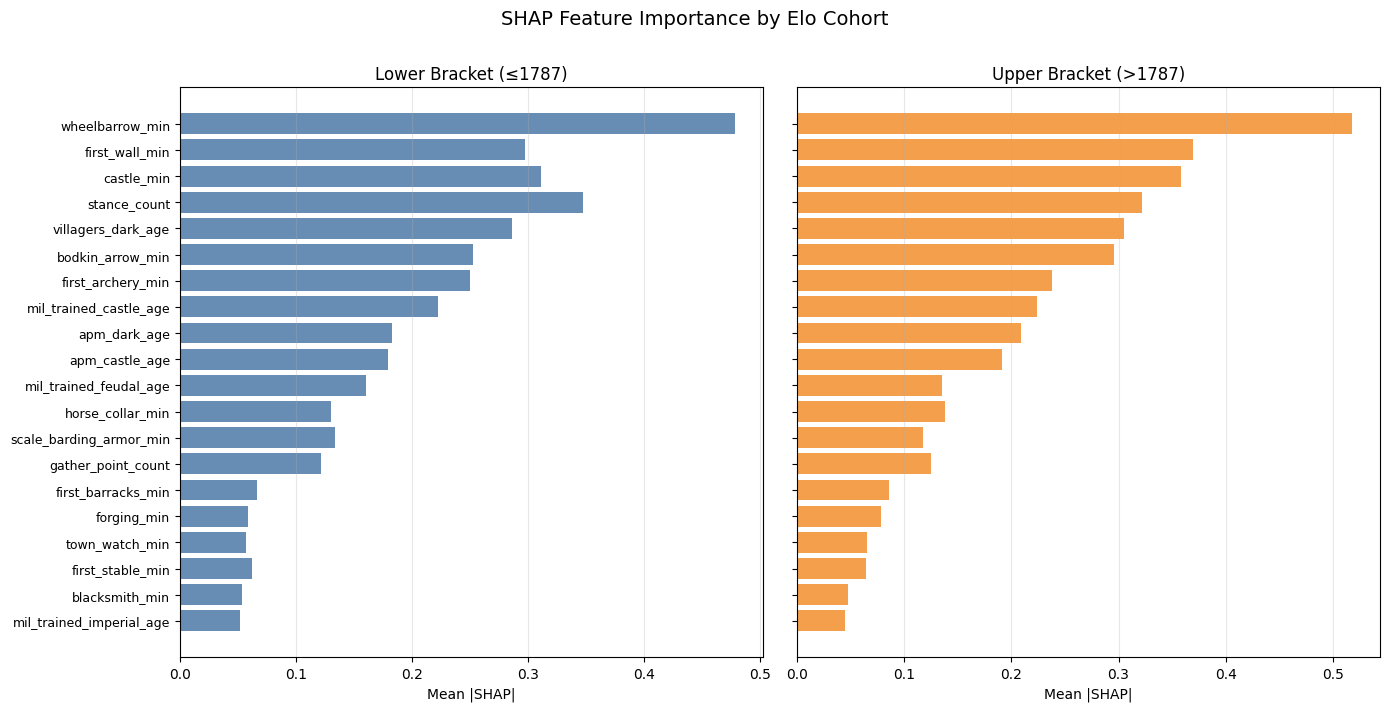

Saved shap_cohort_comparison.png


In [12]:
# ── Side-by-side cohort bar chart ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

features = cohort_df['feature'].tolist()[::-1]
y_pos = np.arange(len(features))

for ax, col, label, color in [
    (axes[0], 'lower', f'Lower Bracket (≤{elo_median:.0f})', '#4e79a7'),
    (axes[1], 'upper', f'Upper Bracket (>{elo_median:.0f})', '#f28e2b'),
]:
    vals = cohort_df.set_index('feature').loc[features, col].values
    ax.barh(y_pos, vals, color=color, alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features, fontsize=9)
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Mean |SHAP|', fontsize=10)
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('SHAP Feature Importance by Elo Cohort', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'shap_cohort_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved shap_cohort_comparison.png')

### 4a. Domain Interpretation

**What to look for:**
- Features that appear in the top 10 for *both* cohorts are universal win drivers in this Elo range.
- Features that appear only in the lower bracket top 10 represent skill gaps that matter most
  at 1500–1790 but become table-stakes for higher-bracket players.
- Features dominant only in the upper bracket represent the micro/macro decisions that
  separate players in the 1790–1900 range where fundamentals are already solid.

**Key AOE2 context:**
- `feudal_min_delta`: Feudal time gap is almost always the top signal — clicking up faster
  gives map control, scouting advantage, and earlier pressure.
- `castle_min_delta`: Castle age timing determines whether you can play Knights/Crossbows/Unique
  units before your opponent; large impact at both brackets.
- `move_count_delta` / `order_count_delta`: APM proxy — reflects how actively you're managing
  villagers and military. More impactful at lower brackets where activity gaps are larger.
- `gold_mining_min_delta`: Starting gold faster fuels military production; often overlooked.
- `hand_cart_min_delta`: One of the highest Cohen's d features — late hand cart is a common
  mistake at 1600–1800 that directly delays villager production efficiency.

## 5. Cohort Comparison Function

Load pre-computed percentile distributions from notebook 05.
Given a player's feature values, return their percentile rank within their Elo cohort.

In [13]:
with open(COHORT_PKL, 'rb') as f:
    cohort_distributions = pickle.load(f)

print('Keys:', list(cohort_distributions.keys()))
print('Sample columns:', list(cohort_distributions['percentiles'].keys())[:5])

Keys: ['feature_cols', 'elo_range', 'elo_median', 'winning_model', 'winning_auc', 'percentiles']
Sample columns: ['villagers_dark_age_delta', 'villagers_feudal_age_delta', 'villagers_castle_age_delta', 'villagers_imperial_age_delta', 'mil_trained_dark_age_delta']


In [14]:
def compute_percentile_rank(value, col, distributions):
    """
    Return the percentile rank of `value` within the stored distribution for `col`.
    Uses linear interpolation between stored percentile breakpoints [10,25,50,75,90].
    Returns None if col not in distributions or value is NaN.
    """
    if pd.isna(value):
        return None
    percs = distributions.get('percentiles', {}).get(col)
    if percs is None:
        return None
    breakpoints = [10, 25, 50, 75, 90]
    vals = [percs[p] for p in breakpoints]
    if value <= vals[0]:
        return 10.0
    if value >= vals[-1]:
        return 90.0
    for i in range(len(vals) - 1):
        if vals[i] <= value <= vals[i+1]:
            frac = (value - vals[i]) / (vals[i+1] - vals[i] + 1e-9)
            return breakpoints[i] + frac * (breakpoints[i+1] - breakpoints[i])
    return 50.0


def get_user_profile(row, delta_cols, distributions):
    """
    Given one row of features_delta.csv, return a dict:
        { col: {'value': float, 'percentile': float} }
    """
    profile = {}
    for col in delta_cols:
        val = row.get(col, np.nan)
        if hasattr(val, 'item'):  # numpy scalar
            val = val.item()
        pct = compute_percentile_rank(val, col, distributions)
        profile[col] = {'value': val, 'percentile': pct}
    return profile

## 6. Recommendation Ranking Function

Priority score is **direction-aware**:

- **Timing features** (`_min`): lower = faster = better.
  `priority = shap_importance × (percentile / 100)` — flags HIGH percentile (you're slow vs peers)
- **Count/activity features**: higher = more = better.
  `priority = shap_importance × (1 − percentile / 100)` — flags LOW percentile (you have less than peers)

A feature only appears in your top recommendations when you are genuinely underperforming peers on it.

In [15]:
# Global SHAP importance per feature (mean |SHAP| across full test set)
global_shap_importance = {
    delta_cols[i]: float(mean_abs_shap[i]) for i in range(len(delta_cols))
}

In [ ]:
# ── Coaching messages ─────────────────────────────────────────────────
# Format: feature_col -> (direction, advice)
# direction: 'negative' means lower value is better (click up faster)
#            'positive' means higher value is better (more villagers)

COACHING_MESSAGES = {
    'feudal_min_delta': (
        'negative',
        'Your feudal time is slower than opponents. Click up earlier — feudal time is the single',
        ' biggest win predictor in this Elo range. Aim to click feudal by 9:30-10:00.',
    ),
    'castle_min_delta': (
        'negative',
        'Your castle age timing is behind. Rushing to Castle unlocks Knights, Crossbows, and Unique',
        ' Units before your opponent. Target castle click-up by 17-18 minutes.',
    ),
    'hand_cart_min_delta': (
        'negative',
        'You research Hand Cart later than opponents. Hand Cart is one of the most cost-efficient',
        ' villager upgrades — delay hurts your economy for the rest of the game.',
    ),
    'gold_mining_min_delta': (
        'negative',
        'You start mining gold later than opponents. Getting gold miners up early funds your military',
        ' production and prevents being out-numbered when pressure comes.',
    ),
    'loom_min_delta': (
        'negative',
        'You research Loom later than opponents. Loom is critical for villager survival during early',
        ' scout rushes — research it within the first 2 minutes.',
    ),
    'imperial_min_delta': (
        'negative',
        'Your Imperial Age timing lags. In late-game scenarios Imperial timing determines access to',
        ' Trebuchets, Paladins, and elite upgrades before your opponent can respond.',
    ),
    'move_count_delta': (
        'positive',
        'Your move command count is lower than opponents, suggesting lower active micro.',
        ' Try to keep units moving, harass more, and actively scout with your military.',
    ),
    'order_count_delta': (
        'positive',
        'Fewer order commands means less active villager management.',
        ' Focus on queuing villagers consistently and issuing explicit gather orders after builds.',
    ),
    'villagers_feudal_age_delta': (
        'positive',
        'You have fewer villagers when reaching Feudal Age than opponents.',
        ' Push for 6 villagers on food before clicking up — idle TC time kills your economy.',
    ),
    'villagers_castle_age_delta': (
        'positive',
        'Fewer villagers at Castle Age means your economy is behind.',
        ' Keep TC always producing. Never let it go idle between ages.',
    ),
    'mil_trained_feudal_age_delta': (
        'positive',
        'You train fewer military units in Feudal Age than opponents.',
        ' Even 2-3 scouts or spearmen provide map control and deny opponent scouting.',
    ),
    'mil_trained_castle_age_delta': (
        'positive',
        'Fewer Castle Age military units trained. Build 1-2 production buildings immediately',
        ' upon entering Castle Age and keep them queued continuously.',
    ),
    'first_barracks_min_delta': (
        'negative',
        'Your Barracks is built later than opponents. Build Barracks before clicking Feudal',
        ' so you can immediately produce military upon advancing.',
    ),
    'first_archery_min_delta': (
        'negative',
        'Your Archery Range timing is late. Archery Ranges in Feudal enable early Archer pressure',
        ' that can win the game outright or force defensive plays from opponents.',
    ),
    'first_stable_min_delta': (
        'negative',
        'You build your Stable later than opponents. Early Stables enable Scout Cavalry and',
        ' Castle-age Knights — critical for applying and defending pressure.',
    ),
    'blacksmith_min_delta': (
        'negative',
        'Blacksmith timing is behind. Blacksmith research (Fletching, Scale Mail) in Feudal Age',
        ' provides critical combat upgrades that compound across the entire game.',
    ),
}

print(f'Coaching messages defined for {len(COACHING_MESSAGES)} features')

In [17]:
def rank_recommendations(user_profile, global_shap_importance, top_n=5):
    """
    Rank features by coaching priority, direction-aware:

    - Timing features (_min): lower delta = faster = better.
      Weakness = high percentile (you are slow relative to peers).
      priority = shap_importance * (percentile / 100)

    - Count/activity features: higher delta = more = better.
      Weakness = low percentile (you have less than peers).
      priority = shap_importance * (1 - percentile / 100)

    Parameters
    ----------
    user_profile : dict  {col: {'value': float, 'percentile': float}}
    global_shap_importance : dict  {col: float}
    top_n : int

    Returns
    -------
    pd.DataFrame with columns: feature, value, percentile, shap_importance, priority
    """
    # Timing features: earlier (lower value) is better -- flag HIGH percentile
    LOWER_IS_BETTER_COLS = {col for col in user_profile if '_min' in col}

    rows = []
    for col, info in user_profile.items():
        pct = info.get('percentile')
        if pct is None:
            continue
        shap_imp = global_shap_importance.get(col, 0.0)
        if col in LOWER_IS_BETTER_COLS:
            # High percentile = you are slower than peers = weakness
            priority = shap_imp * (pct / 100.0)
        else:
            # Low percentile = you have less than peers = weakness
            priority = shap_imp * (1.0 - pct / 100.0)
        rows.append({
            'feature': col.replace('_delta', ''),
            'feature_col': col,
            'value': info['value'],
            'percentile': pct,
            'shap_importance': shap_imp,
            'priority': priority,
        })
    rec_df = pd.DataFrame(rows).sort_values('priority', ascending=False)
    return rec_df.head(top_n).reset_index(drop=True)

In [ ]:
def print_coaching_report(rec_df):
    """Print a formatted coaching report from recommendation dataframe."""
    print('=' * 65)
    print('  PERSONALIZED ELO COACH — TOP RECOMMENDATIONS')
    print('=' * 65)
    for rank, row in rec_df.iterrows():
        feat = row['feature_col']
        pct = row['percentile']
        val = row['value']
        priority = row['priority']
        print(f'')
        print(f'#{rank+1}  {row["feature"]}  (priority={priority:.4f})')
        print(f'    Your delta vs opponent: {val:+.2f}')
        pct_int = int(round(pct))
        suffix = 'th' if 11 <= pct_int % 100 <= 13 else {1: 'st', 2: 'nd', 3: 'rd'}.get(pct_int % 10, 'th')
        print(f'    Percentile vs peers:    {pct_int}{suffix}')
        if feat in COACHING_MESSAGES:
            _, *parts = COACHING_MESSAGES[feat]
            msg = ' '.join(parts)
            # wrap at 60 chars
            words = msg.split()
            line = '    '
            for w in words:
                if len(line) + len(w) + 1 > 64:
                    print(line)
                    line = '    ' + w
                else:
                    line += ' ' + w if line.strip() else '    ' + w
            if line.strip():
                print(line)
    print()
    print('=' * 65)

## 7. End-to-End Test on Personal Replays

Identify games from `parsed_replays.csv` where `profile_id == MY_PROFILE_ID`.
Reconstruct the delta row for those games, with the user's stats as the reference.
Apply recommendation ranking to the most recent 5 games.

In [19]:
replays = pd.read_csv(REPLAYS_CSV)
print(f'Loaded {len(replays)} player-rows from parsed_replays.csv')
print('Columns:', list(replays.columns[:10]), '...')

Loaded 350 player-rows from parsed_replays.csv
Columns: ['filepath', 'map_id', 'rated', 'num_players', 'duration_min', 'player_num', 'profile_id', 'player_name', 'civilization_id', 'is_me'] ...


In [20]:
# Find all games that contain the user
user_games = replays[replays['profile_id'] == MY_PROFILE_ID]['filepath'].unique()
print(f'Found {len(user_games)} games featuring profile_id {MY_PROFILE_ID}')

Found 141 games featuring profile_id 3134896


In [21]:
# For each personal game, reconstruct delta with user as reference player
personal_rows = []

# Numeric feature columns available in parsed_replays.csv
# (same set used in notebook 03 feature engineering)
NON_DELTA_COLS = {
    'filepath', 'map_id', 'rated', 'num_players', 'player_num',
    'profile_id', 'player_name', 'is_me', 'result', 'resigned',
    'resign_time_min', 'civilization_id', 'elo', 'duration_min',
    'thresholds', 'military_buildings_placed',
}

available_feature_cols = [
    c for c in replays.columns
    if c not in NON_DELTA_COLS
    and replays[c].dtype in ['float64', 'int64', 'float32', 'int32']
]
print(f'{len(available_feature_cols)} numeric feature columns in parsed_replays.csv')

for fp in user_games:
    game = replays[replays['filepath'] == fp]
    me_rows  = game[game['profile_id'] == MY_PROFILE_ID]
    opp_rows = game[game['profile_id'] != MY_PROFILE_ID]
    if len(me_rows) != 1 or len(opp_rows) != 1:
        continue
    me  = me_rows.iloc[0]
    opp = opp_rows.iloc[0]
    if pd.isna(me.get('result', np.nan)):
        continue
    row = {'filepath': fp}
    for col in available_feature_cols:
        delta_col = col + '_delta'
        if delta_col in delta_cols:
            row[delta_col] = me[col] - opp[col]
    row['p1_elo'] = me.get('elo', np.nan)
    row['result'] = int(me['result'])
    personal_rows.append(row)

personal_df = pd.DataFrame(personal_rows)
print(f'Reconstructed {len(personal_df)} personal delta rows')
personal_df.head(3)

70 numeric feature columns in parsed_replays.csv
Reconstructed 141 personal delta rows


,filepath,villagers_dark_age_delta,villagers_feudal_age_delta,villagers_castle_age_delta,villagers_imperial_age_delta,mil_trained_dark_age_delta,mil_trained_feudal_age_delta,mil_trained_castle_age_delta,mil_trained_imperial_age_delta,apm_dark_age_delta,...,gambeson_min_delta,squires_min_delta,chemistry_min_delta,barracks_count_delta,stable_count_delta,archery_count_delta,blacksmith_count_delta,market_count_delta,p1_elo,result
0,C:\Users\liher\Games\Age of Empires 2 DE\76561...,-9,0,21,0,-2,-6,-20,0,-182,...,NaN,NaN,NaN,0,0,0,0,0,1715,1
1,C:\Users\liher\Games\Age of Empires 2 DE\76561...,9,-3,0,0,0,15,0,0,-233,...,NaN,NaN,NaN,1,-1,0,0,0,1745,1
2,C:\Users\liher\Games\Age of Empires 2 DE\76561...,1,-3,0,0,-3,-2,0,0,-359,...,NaN,NaN,NaN,0,0,0,1,1,1578,1


In [22]:
# ── Run recommendations on the most recent 5 personal games ───────────
sample = personal_df.tail(5).reset_index(drop=True)

for i, game_row in sample.iterrows():
    fp_short = str(game_row['filepath']).split('/')[-1].split('\\')[-1]
    result_str = 'WIN' if game_row['result'] == 1 else 'LOSS'
    elo_val = game_row.get('p1_elo', 'N/A')
    print(f'\n>>> Game {i+1}: {fp_short}  |  {result_str}  |  Elo ~{elo_val}')

    profile = get_user_profile(game_row.to_dict(), delta_cols, cohort_distributions)
    rec_df  = rank_recommendations(profile, global_shap_importance, top_n=5)
    print_coaching_report(rec_df)


>>> Game 1: MP Replay v101.103.31214.0 @2026.02.17 134122 (1).aoe2record  |  LOSS  |  Elo ~1894
  PERSONALIZED ELO COACH — TOP RECOMMENDATIONS

#1  wheelbarrow_min  (priority=0.4430)
    Your delta vs opponent: +13.92
    Percentile vs peers:    90th

#2  first_wall_min  (priority=0.2936)
    Your delta vs opponent: +23.32
    Percentile vs peers:    90th

#3  first_archery_min  (priority=0.2142)
    Your delta vs opponent: +3.20
    Percentile vs peers:    87th

#4  castle_min  (priority=0.1805)
    Your delta vs opponent: +0.52
    Percentile vs peers:    55th
        Your castle age timing is behind. Rushing to Castle
    unlocks Knights, Crossbows, and Unique Units before your
    opponent. Target castle click-up by 17-18 minutes.

#5  apm_dark_age  (priority=0.1737)
    Your delta vs opponent: -380.00
    Percentile vs peers:    10th


>>> Game 2: MP Replay v101.103.31214.0 @2026.02.17 020237 (1).aoe2record  |  WIN  |  Elo ~1874
  PERSONALIZED ELO COACH — TOP RECOMMENDATIONS

#1 

## 8. User Delta Profile vs Population Median

Visualize the user's average delta across all personal games against
the population median (0 by construction for a balanced dataset).
Features where the user is systematically below 0 are areas of weakness.

In [ ]:
if len(personal_df) == 0:
    print('No personal games found — skipping profile plot.')
else:
    # Average delta per feature across all personal games
    user_means = personal_df[delta_cols].mean()

    # Show top 20 features by mean |SHAP| for readability
    top20 = shap_df['feature'].tolist()  # already sorted by mean |SHAP|
    feature_to_col = {c.replace('_delta',''): c for c in delta_cols}
    top20_cols = [feature_to_col[f] for f in top20 if f in feature_to_col]

    labels = [c.replace('_delta','') for c in top20_cols]
    vals   = [user_means.get(c, 0.0) for c in top20_cols]
    colors = ['#2ca02c' if v >= 0 else '#d62728' for v in vals]

    fig, ax = plt.subplots(figsize=(10, 7))
    y_pos = np.arange(len(labels))
    ax.barh(y_pos, vals, color=colors, alpha=0.8)
    ax.axvline(0, color='black', linewidth=1.0, linestyle='-')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Mean delta (me − opponent)', fontsize=11)
    ax.set_title('Your Average Delta Profile vs Opponent (Personal Games)', fontsize=13)

    green_patch = mpatches.Patch(color='#2ca02c', label='Advantage (positive delta)')
    red_patch   = mpatches.Patch(color='#d62728', label='Disadvantage (negative delta)')
    ax.legend(handles=[green_patch, red_patch], loc='lower right', fontsize=9)

    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / 'user_delta_profile.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved user_delta_profile.png')

## 9. Summary

| Step | Output |
|------|--------|
| Global SHAP beeswarm | `plots/shap_beeswarm_global.png` |
| Global SHAP bar chart | `plots/shap_bar_global.png` |
| Cohort comparison | `plots/shap_cohort_comparison.png` |
| User delta profile | `plots/user_delta_profile.png` |
| Coaching recommendations | Printed to notebook output per game |

**Interpretation guide:**
- A feature with a **negative delta** in the user profile means the user is consistently
  slower/worse than their opponents on that metric.
- Cross-reference with the SHAP bar chart: features that are both high-SHAP *and* negative
  in your delta profile are your highest-priority improvement areas.
- The coaching report uses a direction-aware priority: timing features flag high percentile (you're slow), count features flag low percentile (you have less). Only genuine weaknesses surface.